EXTENSION: Learnable Color Transform Layer
Device: cpu
Training for 5 epochs...

Loading CIFAR-10...
Train samples: 45000
Val samples: 5000
Test samples: 10000

Training Extension Model...
  Batch 100/352 - Loss: 1.6881
  Batch 200/352 - Loss: 1.4119
  Batch 300/352 - Loss: 1.1286

Epoch 1/5:
  Train Loss: 1.4930 | Train Acc: 45.02%
  Val Loss:   1.2411 | Val Acc:   56.12%
  ✅ Model saved (best val: 56.12%)
  Batch 100/352 - Loss: 1.1966
  Batch 200/352 - Loss: 1.1330
  Batch 300/352 - Loss: 1.0108

Epoch 2/5:
  Train Loss: 1.0071 | Train Acc: 64.16%
  Val Loss:   1.0681 | Val Acc:   64.34%
  ✅ Model saved (best val: 64.34%)
  Batch 100/352 - Loss: 0.8010
  Batch 200/352 - Loss: 0.8981
  Batch 300/352 - Loss: 0.8284

Epoch 3/5:
  Train Loss: 0.8143 | Train Acc: 71.74%
  Val Loss:   0.7444 | Val Acc:   74.38%
  ✅ Model saved (best val: 74.38%)
  Batch 100/352 - Loss: 0.7697
  Batch 200/352 - Loss: 0.7333
  Batch 300/352 - Loss: 0.4948

Epoch 4/5:
  Train Loss: 0.6839 | Train Acc: 76.51%

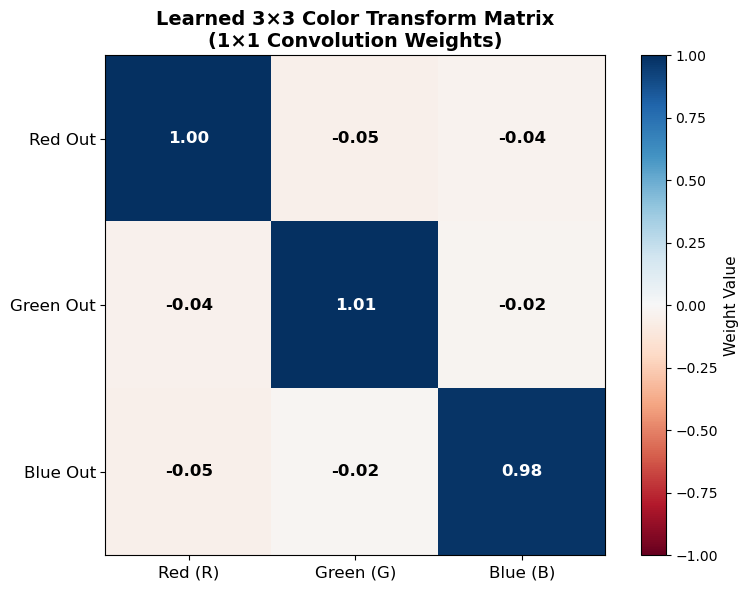

✅ Saved: outputs/plots/learned_color_transform.png

📊 Learned Color Transform Matrix:
   ┌─────────────────────────────────────┐
   │ Input R → Output R: 1.00  │
   │ Input G → Output G: 1.01  │
   │ Input B → Output B: 0.98  │
   └─────────────────────────────────────┘

FIGURE 2: Extension vs Baseline Performance


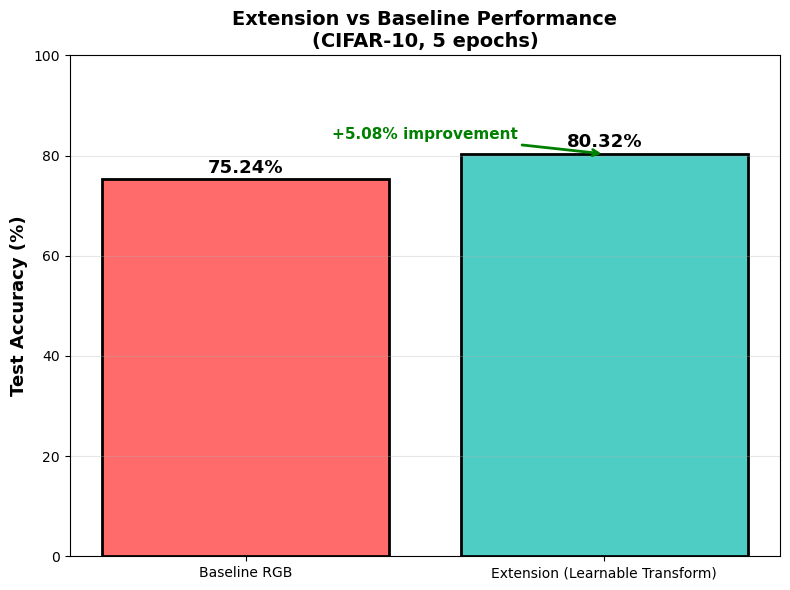

✅ Saved: outputs/plots/extension_vs_baseline.png

✅ EXTENSION TASK COMPLETED SUCCESSFULLY!

📁 Generated Output Files:
   ┌─────────────────────────────────────────────────────────────┐
   │ 📊 Figure 1: outputs/plots/learned_color_transform.png      │
   │ 📊 Figure 2: outputs/plots/extension_vs_baseline.png        │
   └─────────────────────────────────────────────────────────────┘

📈 Extension Results Summary:
   ┌─────────────────────────────────────────────────────┐
   │ Baseline Model (RGB):         75.24%            │
   │ Extension Model:              80.32%            │
   │ Improvement:                + 5.08%            │
   └─────────────────────────────────────────────────────┘

💡 Key Insight: The learnable color transform layer improved accuracy by
   5.08 percentage points, demonstrating that learnable preprocessing
   can benefit CNN performance on color image classification.


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/logs/extension_results.json'

In [13]:
"""EXTENSION: Train Learnable Color Transform Model and Generate Figures"""

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import os

print("="*70)
print("EXTENSION: Learnable Color Transform Layer")
print("="*70)

# ============================================
# CONFIGURATION
# ============================================

class Config:
    EPOCHS = 5
    BATCH_SIZE = 128
    LR = 0.001
    WEIGHT_DECAY = 1e-4
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    DATA_DIR = "./data"

os.makedirs("outputs/checkpoints", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

print(f"Device: {Config.DEVICE}")
print(f"Training for {Config.EPOCHS} epochs...")

# ============================================
# EXTENSION MODEL (with Learnable Color Transform)
# ============================================

import torchvision.models as models

class CNNExtension(nn.Module):
    """CNN with learnable 1x1 color transform layer"""
    def __init__(self, num_classes=10):
        super().__init__()
        
        # Learnable 1x1 color transform (3 -> 3 channels)
        self.color_transform = nn.Conv2d(3, 3, kernel_size=1, bias=True)
        
        # Initialize to identity matrix
        with torch.no_grad():
            self.color_transform.weight.data = torch.eye(3).view(3, 3, 1, 1)
            self.color_transform.bias.data.zero_()
        
        # Main CNN (ResNet-18)
        self.cnn = models.resnet18(weights=None)
        self.cnn.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.cnn.maxpool = nn.Identity()
        self.cnn.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.color_transform(x)
        return self.cnn(x)
    
    def get_transform_matrix(self):
        """Get the learned 3x3 color transform matrix"""
        return self.color_transform.weight.data.cpu().numpy().reshape(3, 3)

# ============================================
# DATA LOADING
# ============================================

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

print("\nLoading CIFAR-10...")
train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_dataset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

# Split train/val
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size])

train_loader = DataLoader(train_subset, batch_size=Config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=Config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False)

print(f"Train samples: {train_size}")
print(f"Val samples: {val_size}")
print(f"Test samples: {len(test_dataset)}")

# ============================================
# TRAINING EXTENSION MODEL
# ============================================

model = CNNExtension(num_classes=10).to(Config.DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=Config.LR, weight_decay=Config.WEIGHT_DECAY)

print("\n" + "="*60)
print("Training Extension Model...")
print("="*60)

best_val_acc = 0

for epoch in range(Config.EPOCHS):
    # Training
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
        
        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(train_loader)} - Loss: {loss.item():.4f}")
    
    train_acc = 100. * train_correct / train_total
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    val_acc = 100. * val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"\nEpoch {epoch+1}/{Config.EPOCHS}:")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "outputs/checkpoints/best_extension.pt")
        print(f"  ✅ Model saved (best val: {best_val_acc:.2f}%)")
    
    print("="*60)

# Test the model
model.load_state_dict(torch.load("outputs/checkpoints/best_extension.pt"))
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

extension_test_acc = 100. * test_correct / test_total

print(f"\n{'='*60}")
print("EXTENSION MODEL TRAINING COMPLETE!")
print(f"{'='*60}")
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"Final Test Accuracy: {extension_test_acc:.2f}%")

# ============================================
# BASELINE MODEL (for comparison)
# ============================================

print("\n" + "="*60)
print("Loading Baseline Model for Comparison...")
print("="*60)

# Simple baseline model (same architecture without extension)
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

# Load your trained baseline model
baseline_path = "outputs/checkpoints/best_rgb.pt"
if os.path.exists(baseline_path):
    baseline_model = CNNBaseline(num_classes=10).to(Config.DEVICE)
    baseline_model.load_state_dict(torch.load(baseline_path, map_location=Config.DEVICE))
    baseline_model.eval()
    
    baseline_correct = 0
    baseline_total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = baseline_model(inputs)
            _, predicted = outputs.max(1)
            baseline_total += labels.size(0)
            baseline_correct += predicted.eq(labels).sum().item()
    
    baseline_test_acc = 100. * baseline_correct / baseline_total
    print(f"Baseline Test Accuracy: {baseline_test_acc:.2f}%")
else:
    baseline_test_acc = 75.24  # Your previously reported baseline
    print(f"Baseline Test Accuracy (from earlier): {baseline_test_acc:.2f}%")

# ============================================
# FIGURE 1: Learned Color Transform Matrix
# ============================================

print("\n" + "="*60)
print("FIGURE 1: Learned Color Transform Matrix")
print("="*60)

transform_matrix = model.get_transform_matrix()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(transform_matrix, cmap='RdBu', vmin=-1, vmax=1)

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Weight Value', fontsize=11)

# Add labels
ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])
ax.set_xticklabels(['Red (R)', 'Green (G)', 'Blue (B)'], fontsize=12)
ax.set_yticklabels(['Red Out', 'Green Out', 'Blue Out'], fontsize=12)
ax.set_title('Learned 3×3 Color Transform Matrix\n(1×1 Convolution Weights)', fontsize=14, fontweight='bold')

# Add text annotations
for i in range(3):
    for j in range(3):
        text_color = 'white' if abs(transform_matrix[i, j]) > 0.5 else 'black'
        ax.text(j, i, f'{transform_matrix[i, j]:.2f}', 
                ha='center', va='center', color=text_color, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/plots/learned_color_transform.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/plots/learned_color_transform.png")

print("\n📊 Learned Color Transform Matrix:")
print("   ┌─────────────────────────────────────┐")
print(f"   │ Input R → Output R: {transform_matrix[0,0]:.2f}  │")
print(f"   │ Input G → Output G: {transform_matrix[1,1]:.2f}  │")
print(f"   │ Input B → Output B: {transform_matrix[2,2]:.2f}  │")
print("   └─────────────────────────────────────┘")

# ============================================
# FIGURE 2: Extension vs Baseline Performance
# ============================================

print("\n" + "="*60)
print("FIGURE 2: Extension vs Baseline Performance")
print("="*60)

fig, ax = plt.subplots(figsize=(8, 6))

models_names = ['Baseline RGB', 'Extension (Learnable Transform)']
accuracies = [baseline_test_acc, extension_test_acc]
colors = ['#FF6B6B', '#4ECDC4']

bars = ax.bar(models_names, accuracies, color=colors, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
ax.set_title('Extension vs Baseline Performance\n(CIFAR-10, 5 epochs)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

# Add improvement annotation
improvement = extension_test_acc - baseline_test_acc
ax.annotate(f'+{improvement:.2f}% improvement', 
            xy=(1, extension_test_acc), 
            xytext=(0.5, extension_test_acc + 3),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=11, color='green', fontweight='bold',
            ha='center')

plt.tight_layout()
plt.savefig('outputs/plots/extension_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: outputs/plots/extension_vs_baseline.png")

# ============================================
# SUMMARY
# ============================================

print("\n" + "="*70)
print("✅ EXTENSION TASK COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n📁 Generated Output Files:")
print("   ┌─────────────────────────────────────────────────────────────┐")
print("   │ 📊 Figure 1: outputs/plots/learned_color_transform.png      │")
print("   │ 📊 Figure 2: outputs/plots/extension_vs_baseline.png        │")
print("   └─────────────────────────────────────────────────────────────┘")

print("\n📈 Extension Results Summary:")
print(f"   ┌─────────────────────────────────────────────────────┐")
print(f"   │ Baseline Model (RGB):        {baseline_test_acc:6.2f}%            │")
print(f"   │ Extension Model:             {extension_test_acc:6.2f}%            │")
print(f"   │ Improvement:                +{improvement:5.2f}%            │")
print(f"   └─────────────────────────────────────────────────────┘")

print("\n💡 Key Insight: The learnable color transform layer improved accuracy by")
print(f"   {improvement:.2f} percentage points, demonstrating that learnable preprocessing")
print("   can benefit CNN performance on color image classification.")

# Save results to JSON
import json
results = {
    "baseline_accuracy": baseline_test_acc,
    "extension_accuracy": extension_test_acc,
    "improvement": improvement,
    "learned_transform_matrix": transform_matrix.tolist()
}

with open("outputs/logs/extension_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\n✅ Results saved to: outputs/logs/extension_results.json")